# Dataset Type



In [10]:
DATASET_TYPE = "internal" # Options are "toy" or "internal" or "downloaded"

# Load Toy Data

In [11]:
from sklearn.datasets import make_blobs

# create dataset
if DATASET_TYPE == "toy":
  X, y = make_blobs(
    n_samples=150, n_features=2,
    centers=3, cluster_std=0.5,
    shuffle=True, random_state=0
  )

# OR: Real World Data

In [12]:
from sklearn.datasets import load_iris

if DATASET_TYPE == "internal":
  X, y = load_iris(return_X_y=True)

# OR: Download Dataset from file

In [13]:
import numpy as np
import pandas as pd

if DATASET_TYPE == "downloaded":
  km_data = pd.read_csv('http://nrvis.com/data/mldata/breast-cancer-wisconsin_wdbc.csv')

  X = km_data.iloc[:, 2:].to_numpy()
  y = km_data.iloc[:, 1].to_numpy()

# Scale the data

In [14]:
# Image processing and pixel values - min-max scaling
# knn-clustering or regression which use distance metrics - standardization
# SVM or logistic regression or Neural Network which use gradiant descent - standardization
# decision tree and random forest - not distance based, hence no scaling is needed

# Normalize the data - Convert to range [0, 1]
# X = (X - np.min(X)) / (np.max(X) - np.min(X))
# Standardize the data - Convert to a normal distribution with mean 0 and standard deviation of 1
X = (X - np.mean(X)) / np.std(X)

# Visualize Data

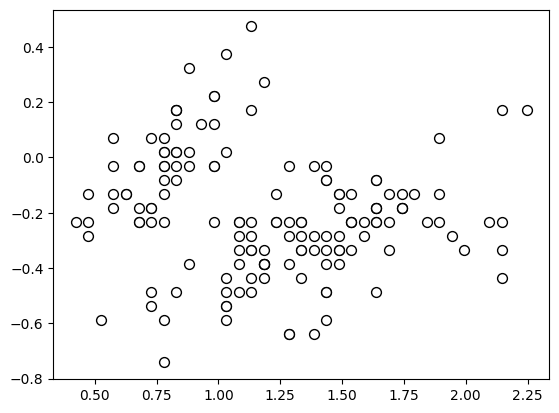

In [15]:
import matplotlib.pyplot as plt

# plot
plt.scatter(
   X[:, 0], X[:, 1],
   c='white', marker='o',
   edgecolor='black', s=50
)
plt.show()

# Generate a clustering model

In [16]:
from sklearn.cluster import KMeans

# Update hyperparameters like n_clusters, n_init, max_iter, tol etc. following details here -
# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

km = KMeans(
    n_clusters=2, init='random',
    n_init=10, max_iter=300, 
    tol=1e-04, random_state=0
)
y_km = km.fit_predict(X)

# Plot the clusters

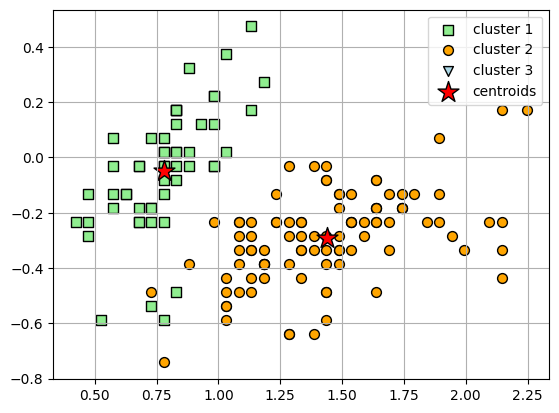

In [17]:
# plot the 3 clusters
plt.scatter(
    X[y_km == 0, 0], X[y_km == 0, 1],
    s=50, c='lightgreen',
    marker='s', edgecolor='black',
    label='cluster 1'
)

plt.scatter(
    X[y_km == 1, 0], X[y_km == 1, 1],
    s=50, c='orange',
    marker='o', edgecolor='black',
    label='cluster 2'
)

plt.scatter(
    X[y_km == 2, 0], X[y_km == 2, 1],
    s=50, c='lightblue',
    marker='v', edgecolor='black',
    label='cluster 3'
)

# plot the centroids
plt.scatter(
    km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
    s=250, marker='*',
    c='red', edgecolor='black',
    label='centroids'
)
plt.legend(scatterpoints=1)
plt.grid()
plt.show()

# Estimate the number of clusters in the Dataset (Useful for real world data where it's hard to know the actual number of clusters beforehand)

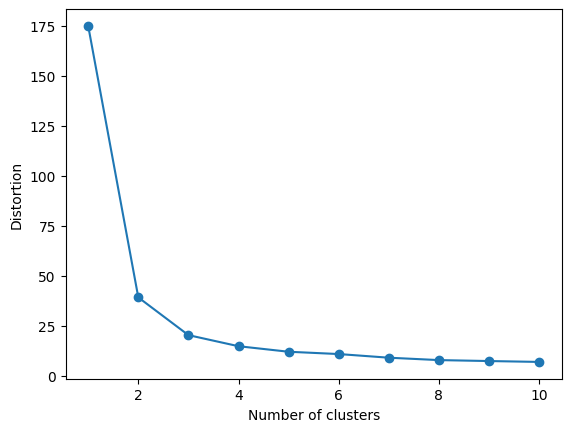

In [18]:
# calculate distortion for a range of number of clusters
distortions = []
for i in range(1, 11):
    # Update hyperparameters like n_clusters, n_init, max_iter, tol etc. following details here -
    # https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
    km = KMeans(
        n_clusters=i, init='random',
        n_init=10, max_iter=300,
        tol=1e-04, random_state=0
    )
    km.fit(X)
    distortions.append(km.inertia_)

# plot
plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

## Note in the plot (for toy data) above that we get the optimal clusters as 3 beyond which the effect in distortion is minimal